In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr

df = pd.read_csv("06. Apoyo desafío - Videojuegos.csv")

df.head()

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.516229,8.243746,1.860090,NaN
1,Juego_1,Nintendo,2019,Acción,9.533212,3.665887,3.882065,97.0
2,Juego_2,PC,2021,Aventura,5.151544,1.357899,1.704018,67.0
3,Juego_3,Xbox,2011,Estrategia,5.303223,5.270208,4.653787,75.0
4,Juego_4,Xbox,2019,Estrategia,10.916740,7.722936,4.292064,65.0


In [2]:
# 2. Creación de la columna Ventas_Globales
df['Ventas_Globales'] = df['Ventas_NA'] + df['Ventas_EU'] + df['Ventas_JP']

# 3. Manejo de valores nulos en Critica_Puntaje
nulos_antes = df['Critica_Puntaje'].isnull().sum()
mediana_critica = df['Critica_Puntaje'].median()
df['Critica_Puntaje'] = df['Critica_Puntaje'].fillna(mediana_critica)
nulos_despues = df['Critica_Puntaje'].isnull().sum()

print(f"Cantidad de nulos ANTES de la imputación: {nulos_antes}")
print(f"Cantidad de nulos DESPUÉS de la imputación: {nulos_despues}")

Cantidad de nulos ANTES de la imputación: 10
Cantidad de nulos DESPUÉS de la imputación: 0


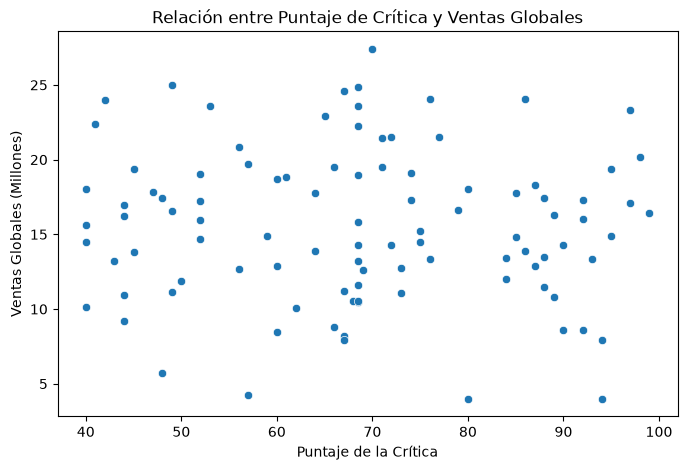

Coeficiente de correlación de Pearson (r): -0.0543


In [3]:
# Gráfico de dispersión (Scatterplot)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Critica_Puntaje', y='Ventas_Globales')
plt.title('Relación entre Puntaje de Crítica y Ventas Globales')
plt.xlabel('Puntaje de la Crítica')
plt.ylabel('Ventas Globales (Millones)')
plt.show()

# Cálculo del coeficiente de correlación de Pearson
r_pearson, p_value = pearsonr(df['Critica_Puntaje'], df['Ventas_Globales'])
print(f"Coeficiente de correlación de Pearson (r): {r_pearson:.4f}")

In [4]:
# Definición de variables
X = df['Critica_Puntaje']
y = df['Ventas_Globales']

# Agregar la constante (intercepto) para statsmodels
X_sm = sm.add_constant(X)

# Implementar y ajustar el modelo
modelo = sm.OLS(y, X_sm).fit()

# Mostrar el resumen
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        Ventas_Globales   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.2903
Date:                Sun, 05 Jul 2026   Prob (F-statistic):              0.591
Time:                        19:18:21   Log-Likelihood:                -304.20
No. Observations:                 100   AIC:                             612.4
Df Residuals:                      98   BIC:                             617.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              16.6728      2.148     